# Evoked noise correlations (GLM-residualized) vs LDA 1
Window 0–0.2 s. For each session, remove the effects of **stimulus side, contrast, choice, and feedback** by OLS regression (residuals = noise), after **balancing trials by choice×feedback**. Pairwise correlations across **all neurons** in the recording (not per region).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle, os, hashlib
from collections import defaultdict
from scipy.stats import pearsonr, spearmanr
import warnings
warnings.filterwarnings('ignore')
sns.set_style('whitegrid'); plt.rcParams['figure.facecolor']='white' 

In [2]:
prefix = '/home/ines/repositories/representation_learning_variability/paper-individuality/'
firing_rates_dir = prefix + 'data/firing_rates/'
trials_path = prefix + '4_mice/all_trials_04-05-2026'
out_dir = prefix + 'neural/'

WINDOW = (0.0, 0.2)
REGION_FILTER = 'drop_root'   # neurons to include; pairs are formed WITHIN region
MIN_RATE = 0.5                # Hz
MIN_TRIALS = 50               # usable (balanced) trials per session
MIN_NEURONS = 5
SEED = 0
BALANCE_CHOICE_FEEDBACK = False   # redundant once choice/feedback are regressed out

def area_mask(a):
    if REGION_FILTER is None: return np.ones(len(a), dtype=bool)
    if REGION_FILTER == 'drop_root': return (a != 'root').values
    return a.isin(REGION_FILTER).values

lda = pd.read_pickle(prefix + 'clustering/mouse_LDA_5_bins_cut19-06-2026').rename(columns={0: 'lda_1'})
trials_df = pd.read_parquet(trials_path)
# per-session trial-level behaviour: choice + feedback(correct)
trial_beh = {s: g.set_index('trial_id')[['choice', 'correct']] for s, g in trials_df.groupby('session')}

def session_seed(s): return (int(hashlib.md5(s.encode()).hexdigest()[:8], 16) + SEED) % (2**32)

def partial_corr(x, y, z):
    x, y, z = map(lambda v: np.asarray(v, float), (x, y, z))
    Z = np.c_[np.ones_like(z), z]
    rx = x - Z @ np.linalg.lstsq(Z, x, rcond=None)[0]
    ry = y - Z @ np.linalg.lstsq(Z, y, rcond=None)[0]
    return pearsonr(rx, ry)
print("params set")

params set


## Load single-trial evoked rates (+ stimulus side/contrast from condition)

In [3]:
pkl_files = sorted([f for f in os.listdir(firing_rates_dir) if f.startswith('firing_rate_')])
with open(os.path.join(firing_rates_dir, pkl_files[0]), 'rb') as f:
    s0 = pickle.load(f)
tcols = sorted([c for c in s0.columns if c.startswith('t_')], key=lambda x: float(x.split('_')[1]))
tsec = np.array([float(c.split('_')[1]) for c in tcols])
wcols = [c for c, m in zip(tcols, (tsec >= WINDOW[0]) & (tsec <= WINDOW[1])) if m]
print(f"Window {WINDOW}: {len(wcols)} of {len(tcols)} bins")

sess_pivots = defaultdict(list)   # (trials x neurons pivot, area map)
sess_cond = {}
for i, fn in enumerate(pkl_files):
    try:
        with open(os.path.join(firing_rates_dir, fn), 'rb') as f:
            d = pickle.load(f)
        d = d[area_mask(d['area'])]
        if len(d) == 0: continue
        session = d['session'].iloc[0]; d = d.copy()
        d['rate'] = np.nanmean(d[wcols].values, axis=1)
        d['nuid'] = d['pid'].astype(str) + '__' + d['neuron_id'].astype(str)
        sess_pivots[session].append((d.pivot_table(index='trial_id', columns='nuid', values='rate'),
                                     d.groupby('nuid')['area'].first()))
        if session not in sess_cond:
            sess_cond[session] = d.drop_duplicates('trial_id').set_index('trial_id')['condition']
        if (i+1) % 100 == 0: print(f"  {i+1}/{len(pkl_files)} files...")
    except Exception as e:
        print(f"Error {fn}: {e}")
print(f"Sessions: {len(sess_pivots)}")

Window (0.0, 0.2): 12 of 90 bins
  100/380 files...
  200/380 files...
  300/380 files...
Sessions: 244


## Balance trials, regress out task variables, correlate all neuron pairs

In [4]:
pair_session, pair_area, pair_r, pair_geo = [], [], [], []
info = []
for session, parts in sess_pivots.items():
    X = pd.concat([p for p, _ in parts], axis=1)
    areas = pd.concat([a for _, a in parts]); areas = areas[~areas.index.duplicated()]

    # per-trial task variables
    cond = sess_cond[session].reindex(X.index).astype(str)
    side, contrast = cond.str.split('_').str[0], cond.str.split('_').str[1]
    beh = trial_beh.get(session)
    if beh is None: continue
    choice = beh['choice'].reindex(X.index).astype(str)
    feedback = beh['correct'].reindex(X.index).astype(str)
    meta = pd.DataFrame({'side': side, 'contrast': contrast, 'choice': choice, 'feedback': feedback}, index=X.index)
    valid = ~meta.isin(['nan', 'None']).any(axis=1)
    X, meta = X.loc[valid], meta.loc[valid]

    if BALANCE_CHOICE_FEEDBACK:
        grp = meta['choice'] + '|' + meta['feedback']
        nmin = int(grp.value_counts().min())
        rng = np.random.default_rng(session_seed(session))
        chosen = np.concatenate([rng.choice(idx.index.values, nmin, replace=False) for _, idx in grp.groupby(grp)])
        X, meta = X.loc[chosen], meta.loc[chosen]
    if X.shape[0] < MIN_TRIALS: continue

    rates = X.mean(axis=0)
    keep = (rates >= MIN_RATE) & (X.std(axis=0) > 0)
    X = X.loc[:, keep.values]; rates = rates[keep.values]
    areas2 = areas.reindex(X.columns)
    if X.shape[1] < MIN_NEURONS: continue

    # regress out side+contrast+choice+feedback (residual = noise)
    D = pd.get_dummies(meta.astype(str), drop_first=False).astype(float); D['intercept'] = 1.0
    Dv, Xv = D.values, X.values.astype(float)
    R = pd.DataFrame(Xv - Dv @ np.linalg.lstsq(Dv, Xv, rcond=None)[0], index=X.index, columns=X.columns)

    info.append(dict(session=session, n_neurons=X.shape[1], n_trials=X.shape[0], mean_rate=float(rates.mean())))

    # WITHIN-region pairwise correlations
    for region, neurons in areas2.groupby(areas2):
        cols = neurons.index
        if len(cols) < 2: continue
        C = np.corrcoef(R[cols].values, rowvar=False)
        rv = rates[cols].values
        iu, ju = np.triu_indices(len(cols), k=1)
        pair_session.append(np.repeat(session, len(iu)))
        pair_area.append(np.repeat(region, len(iu)))
        pair_r.append(C[iu, ju]); pair_geo.append(np.sqrt(rv[iu] * rv[ju]))

pairs = pd.DataFrame({'session': np.concatenate(pair_session), 'area': np.concatenate(pair_area),
                      'rSC': np.concatenate(pair_r), 'geo_rate': np.concatenate(pair_geo)}).dropna(subset=['rSC'])
info_df = pd.DataFrame(info)
print(f"Pairs: {len(pairs):,} | sessions: {pairs['session'].nunique()} | mean within-region residual r_SC = {pairs['rSC'].mean():.4f}")

Pairs: 578,845 | sessions: 241 | mean within-region residual r_SC = 0.0452


In [5]:
m = pairs['geo_rate'] > 0
b = np.polyfit(np.log(pairs.loc[m, 'geo_rate']), pairs.loc[m, 'rSC'], 1)
pairs['rSC_corrected'] = pairs['rSC'] - np.polyval(b, np.log(pairs['geo_rate'].clip(lower=1e-3))) + pairs['rSC'].mean()
session_df = (pairs.groupby('session').agg(mean_rSC=('rSC','mean'), rSC_rate_corrected=('rSC_corrected','mean'),
              n_pairs=('rSC','size'), geo_rate=('geo_rate','mean')).reset_index().merge(info_df, on='session', how='left'))
pairs.to_parquet(out_dir + 'noise_corr_pairs_evoked_glm_region.parquet')
session_df.to_parquet(out_dir + 'noise_corr_session_evoked_glm_region.parquet')
print(f"rate slope={b[0]:+.4f}; saved {len(pairs):,} pairs, {len(session_df)} sessions")

rate slope=+0.0067; saved 578,845 pairs, 241 sessions


## Residual noise correlation vs LDA 1

In [6]:
nc = session_df.merge(lda[['session', 'lda_1']], on='session').dropna(subset=['mean_rSC', 'lda_1'])
for col, label in [('mean_rSC', 'raw'), ('rSC_rate_corrected', 'rate-corr')]:
    r, p = pearsonr(nc[col], nc['lda_1']); rho, pp = spearmanr(nc[col], nc['lda_1'])
    pr, ppr = partial_corr(nc[col], nc['lda_1'], nc['mean_rate'])
    print(f"all-region {label}: pearson r={r:+.3f} p={p:.3f} | spearman rho={rho:+.3f} p={pp:.3f} | partial(rate) r={pr:+.3f} p={ppr:.3f}")
print(f"n sessions = {len(nc)}\n")

# per-region scan
_reg = pairs.groupby(['session','area'],as_index=False).agg(rSC=('rSC','mean'),geo_rate=('geo_rate','mean'),n_pairs=('rSC','size'))
_reg = _reg.merge(lda[['session','lda_1']], on='session')
base = _reg[_reg['n_pairs']>=10].dropna(subset=['rSC','lda_1'])
rows=[]
for region,g in base.groupby('area'):
    if g['session'].nunique()<15: continue
    n=len(g); r,p=pearsonr(g['rSC'],g['lda_1']); rho,pp=spearmanr(g['rSC'],g['lda_1'])
    pr,ppr=partial_corr(g['rSC'],g['lda_1'],g['geo_rate'])
    zse=1/np.sqrt(n-3); lo,hi=np.tanh(np.arctanh(r)-1.96*zse),np.tanh(np.arctanh(r)+1.96*zse)
    rows.append(dict(region=region,n=n,pearson_r=r,p=p,ci_lo=lo,ci_hi=hi,spearman_p=pp,partial_r=pr,p_partial=ppr))
scan=pd.DataFrame(rows).sort_values('n',ascending=False).reset_index(drop=True)
pd.set_option('display.float_format', lambda v:f'{v:.3f}')
print(scan.to_string(index=False))
print(f"\nRegions tested: {len(scan)} (Bonferroni alpha={0.05/max(1,len(scan)):.4f})")

all-region raw: pearson r=-0.089 p=0.169 | spearman rho=-0.134 p=0.037 | partial(rate) r=-0.077 p=0.232
all-region rate-corr: pearson r=-0.092 p=0.155 | spearman rho=-0.134 p=0.038 | partial(rate) r=-0.074 p=0.255
n sessions = 241

region  n  pearson_r     p  ci_lo  ci_hi  spearman_p  partial_r  p_partial
   CA1 44     -0.061 0.696 -0.351  0.241       0.671     -0.102      0.511
   MRN 41      0.048 0.764 -0.263  0.351       0.700      0.060      0.708
    CP 40      0.204 0.207 -0.115  0.484       0.333      0.197      0.222
    LP 32     -0.179 0.327 -0.497  0.181       0.850     -0.181      0.321
    DG 30      0.011 0.954 -0.351  0.370       0.335      0.009      0.963
   CA3 24      0.033 0.879 -0.376  0.430       0.784     -0.104      0.629
    PO 23      0.121 0.583 -0.307  0.508       0.266      0.107      0.628
   APN 22     -0.070 0.756 -0.478  0.362       0.608     -0.076      0.738
   MOs 20      0.179 0.450 -0.286  0.576       0.596      0.156      0.511
   MOp 20     -0.0

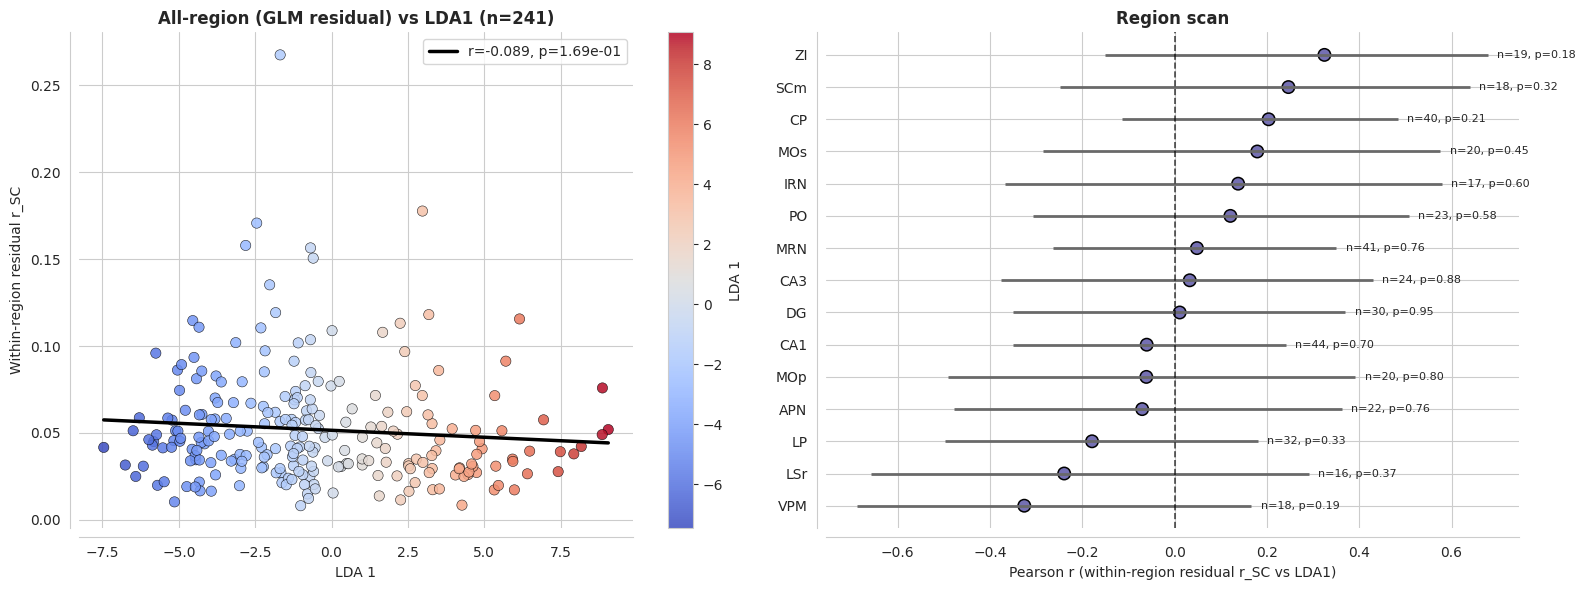

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
x=nc['lda_1'].values; y=nc['mean_rSC'].values; r,p=pearsonr(y,x)
sc=axes[0].scatter(x,y,c=x,cmap='coolwarm',s=55,alpha=0.85,edgecolors='black',linewidth=0.4)
axes[0].plot(np.linspace(x.min(),x.max(),100),np.polyval(np.polyfit(x,y,1),np.linspace(x.min(),x.max(),100)),'k-',lw=2.5,label=f'r={r:.3f}, p={p:.2e}')
fig.colorbar(sc,ax=axes[0]).set_label('LDA 1')
axes[0].set_xlabel('LDA 1'); axes[0].set_ylabel('Within-region residual r_SC')
axes[0].set_title(f'All-region (GLM residual) vs LDA1 (n={len(nc)})',fontweight='bold'); axes[0].legend()
d=scan.sort_values('pearson_r').reset_index(drop=True); yy=np.arange(len(d))
colors=['#d95f02' if pp<0.05 else '#7570b3' for pp in d['p']]
axes[1].hlines(yy,d['ci_lo'],d['ci_hi'],color='dimgray',lw=2)
axes[1].scatter(d['pearson_r'],yy,c=colors,s=80,edgecolors='black',lw=1.1)
axes[1].axvline(0,color='black',ls='--',lw=1.2,alpha=0.7)
for i,row in d.iterrows(): axes[1].text(row['ci_hi']+0.02,i,f"n={int(row['n'])}, p={row['p']:.2f}",va='center',fontsize=8)
axes[1].set_yticks(yy); axes[1].set_yticklabels(d['region'])
axes[1].set_xlabel('Pearson r (within-region residual r_SC vs LDA1)'); axes[1].set_title('Region scan',fontweight='bold')
for ax in axes: sns.despine(ax=ax,offset=6)
plt.tight_layout(); plt.show()